In [1]:
import sys
sys.path.append("../../")

%load_ext autoreload
%autoreload 2

In [2]:
import dsrl.offline_safety_gymnasium  # type: ignore
import gymnasium as gym

import dsrl.infos as dsrl_infos
import numpy as np
import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from dsrl_model.utils.models import ExpCostModel, SafeTransformerCritic, EnsembleValue

In [3]:
def load_cost_model(obs_dim, act_dim, hidden_size, path, device, is_attention=False, horizon=-1):
    if is_attention:
        cost_model = SafeTransformerCritic(
            obs_dim=obs_dim,
            act_dim=act_dim,
            horizon=horizon,
            latent_dim=hidden_size,
            device=device
        )
    else:
        cost_model = ExpCostModel(
            obs_dim=obs_dim + act_dim, hidden_sizes=[hidden_size, hidden_size]
        ).to(device)
    cost_model.load_state_dict(torch.load(path, weights_only=True, map_location=device))
    cost_model.eval()
    return cost_model


def load_value_model(obs_dim, act_dim, hidden_size, path, device):
    value_model = EnsembleValue(
        obs_dim=obs_dim + act_dim,
        hidden_sizes=[hidden_size,],
    ).to(device)
    value_model.load_state_dict(torch.load(path, weights_only=True, map_location=device))
    value_model.eval()
    return value_model

In [4]:
def get_env(task):
    env = gym.make(task)
    obs_space, act_space = env.observation_space, env.action_space
    return env, obs_space.shape[0], act_space.shape[0]

In [5]:
def get_post_processed_dataset(env, data):
    density = 1.0
    cbins, rbins = 10, 50
    max_npb, min_npb = 30, 2
    
    inpaint_ranges = ((0.0, 1.0, 0.0, 0.5),)
    
    data = env.pre_process_data(
        data_dict=data,
        inpaint_ranges=inpaint_ranges,
        density=density,
        cbins=cbins,
        rbins=rbins,
        max_npb=max_npb,
        min_npb=min_npb,
    )
    return data


def get_dataset(env, task):
    data = env.get_dataset()
    data = get_post_processed_dataset(env, data)
    return data

In [6]:
def get_true_cost_info_data(data):
    dones_idx = np.where((data["terminals"] == 1) | (data["timeouts"] == 1))[0]
    reward_trajs, true_cost_trajs = [], []
    rewards, costs = data["rewards"], data["costs"]
    for i in range(dones_idx.shape[0]):
        start = 0 if i == 0 else dones_idx[i - 1] + 1
        end = dones_idx[i] + 1
        reward_trajs.append(np.sum(rewards[start:end]))
        true_cost_trajs.append(np.sum(costs[start:end]))
    return np.array(reward_trajs), np.array(true_cost_trajs)


def get_pred_cost_info_data(data, cost_model, norm=False):
    dones_idx = np.where((data["terminals"] == 1) | (data["timeouts"] == 1))[0]
    pred_cost_trajs = []
    observations, actions = torch.Tensor(data["observations"]), torch.Tensor(data["actions"])
    if norm:
        mu, std = torch.mean(observations, dim=0), torch.std(observations, dim=0)
        observations = (observations - mu) / (std + 1e-6)    
    pred_costs = cost_model(
        torch.cat([observations, actions], dim=1), use_sigmoid=True
    ).detach().squeeze().cpu().numpy()
    for i in range(dones_idx.shape[0]):
        start = 0 if i == 0 else dones_idx[i - 1] + 1
        end = dones_idx[i] + 1
        pred_cost_trajs.append(np.sum(pred_costs[start:end]))
    return np.array(pred_cost_trajs)


def get_pred_value_info_data(data, value_cost, norm=False):
    dones_idx = np.where((data["terminals"] == 1) | (data["timeouts"] == 1))[0]
    observations, actions = torch.Tensor(data["observations"]), torch.Tensor(data["actions"])
    if norm:
        mu, std = torch.mean(observations, dim=0), torch.std(observations, dim=0)
        observations = (observations - mu) / (std + 1e-6)    
    start_idx = np.concatenate([[0,], dones_idx[:-1]+1])
    v1, v2 = value_cost.V(
        torch.cat([observations[start_idx], actions[start_idx]], dim=1)
    )
    pred_value_trajs = torch.max(v1, v2).detach().cpu().numpy()
    return pred_value_trajs


def get_attn_pred_cost_info_data(data, cost_model, horizon, norm=False):
    dones_idx = np.where((data["terminals"] == 1) | (data["timeouts"] == 1))[0]
    pred_cost_trajs = []
    observations, actions = torch.Tensor(data["observations"]), torch.Tensor(data["actions"])
    if norm:
        mu, std = torch.mean(observations, dim=0), torch.std(observations, dim=0)
        observations = (observations - mu) / (std + 1e-6)
    for i in range(dones_idx.shape[0]):
        start = 0 if i == 0 else dones_idx[i - 1] + 1
        end = dones_idx[i] + 1
        o, a = observations[start:end], actions[start:end]
        batch_size = o.shape[0] // horizon
        o, a = o[:batch_size*horizon], a[:batch_size*horizon]
        o, a = o.view(batch_size, horizon, -1), a.view(batch_size, horizon, -1)
        o, a = o.permute(1, 0, 2), a.permute(1, 0, 2)
        c = cost_model(torch.cat([o,a], dim=-1), use_sigmoid=True)
        pred_cost_trajs.append(torch.sum(c).item() * horizon)
    return np.array(pred_cost_trajs)

In [7]:
def traj_binning(traj_cost, bin_size=25):
    min_cost, max_cost = traj_cost.min(), traj_cost.max()
    c = min_cost
    bins = []
    while c < max_cost:
        bins.append([])
        c = min(bin_size + c, max_cost)
    
    for idx, cost in enumerate(traj_cost):
        cost -= min_cost
        i = min(int(cost // bin_size), len(bins)-1)    
        bins[i].append(idx)
    
    return bins

In [15]:
def light_color(color, amount=0.5):
    try:
        c = mcolors.cnames[color]  # convert named color to hex
    except KeyError:
        c = color  # if it's not a named color, it might already be hex or RGB

    rgb = mcolors.to_rgb(c)  # convert to RGB format
    light_color = [(1 - amount) * channel + amount for channel in rgb]  # blend with white
    return light_color


def plot_pred_cost_trajectories(pred_traj_cost, bins, task_name):
    fig, ax = plt.subplots(figsize=(6, 4))
    # color = "red"
    for i, bin in enumerate(bins):
        costs = pred_traj_cost[bin]
        # amount = (0.9 - 0.9/len(bins) * i)
        ax.plot(costs, [i]*len(bin), "o")
    
    ax.set_title(task_name)

In [41]:
task = "OfflineAntVelocityGymnasium-v1"
# task = "OfflinePointButton1Gymnasium-v0"
device = torch.device("cpu")

is_norm = True
norm_type = "norm" if is_norm else "no_norm"

is_attention = False
horizon = 10

cost_model_path = f"/home/returaj/workspace/github/offline_mpc/dsrl_model/runs/safepcl/{task}/{norm_type}/cost_model_1000000.pt"
value_cost_model_path = f"/home/returaj/workspace/github/offline_mpc/dsrl_model/runs/safepcl/{task}/{norm_type}/value_cost_model_280000.pt"

Loading dataset from /home/returaj/.dsrl/datasets/SafetyAntVelocityGymnasium-v1-250-2249.hdf5


load datafile: 100%|██████████| 7/7 [00:07<00:00,  1.09s/it]


rmax = 2976.276611328125, rmin = 6.1519012451171875
cmax = 250.0, cmin = 0.0
before filter: traj num = 2249, transitions num = 2092264
after filter: traj num = 2249


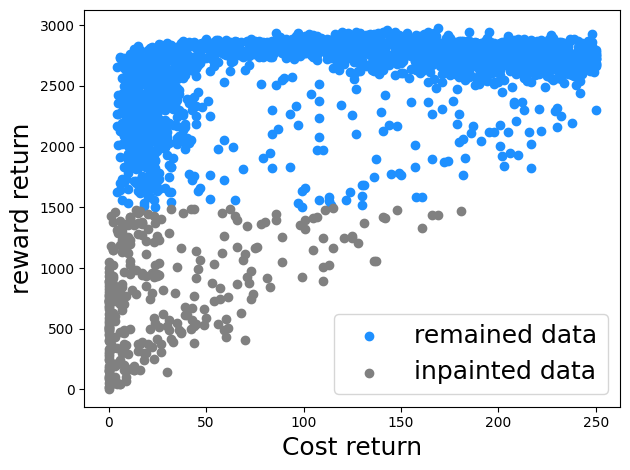

In [42]:
env, obs_dim, act_dim = get_env(task)
data = get_dataset(env, task)

In [43]:
cost_model = load_cost_model(obs_dim, act_dim, 256, cost_model_path, device, is_attention=is_attention, horizon=horizon)

In [44]:
traj_reward, true_traj_cost = get_true_cost_info_data(data)
cost_bins = traj_binning(true_traj_cost)

In [45]:
if is_attention:
    pred_traj_cost = get_attn_pred_cost_info_data(data, cost_model, horizon=10, norm=is_norm)
else:
    pred_traj_cost = get_pred_cost_info_data(data, cost_model, norm=is_norm)

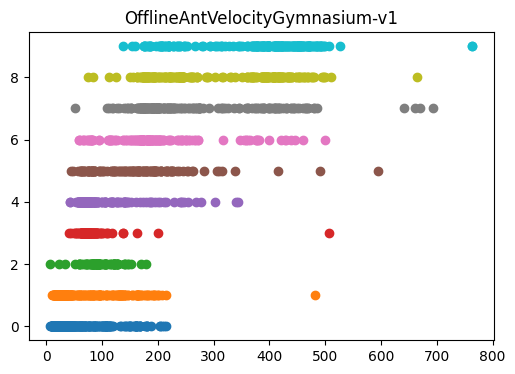

In [46]:
plot_pred_cost_trajectories(pred_traj_cost, cost_bins, task_name=task)

In [41]:
value_model = load_value_model(obs_dim, act_dim, 256, value_cost_model_path, device)

In [42]:
pred_value_cost = get_pred_value_info_data(data, value_model, norm=is_norm)

In [43]:
pred_value_cost.mean(), pred_value_cost.min(), pred_value_cost.max(), pred_value_cost.std()

(38.240517, 14.125288, 71.50286, 12.191437)